In [1]:
import torch
torch.cuda.is_available()

False

In [2]:
# Graph aesthetics settings
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
large = 20; medium = 16; small = 12
colors = ['#66bb6a', '#558ed5', '#dd6a63', '#dcd0ff', '#ffa726', '#8c5eff', '#f44336', '#00bcd4', '#ffc107', '#9c27b0']
text_color = "#404040"

params = {'axes.titlesize': medium,
          'legend.fontsize': small,
          'figure.figsize': (16, 16),
          'axes.labelsize': small,
          'axes.linewidth': 2,
          'xtick.labelsize': small,
          'xtick.color': text_color,
          'ytick.color': text_color,
          'ytick.labelsize': small,
          'axes.edgecolor': text_color,
          'figure.titlesize': small,
          'axes.prop_cycle': cycler(color=colors),
          'axes.titlecolor': text_color,
          'axes.labelcolor': text_color,
         }

plt.rcParams.update(params)
%matplotlib inline

In [3]:
import time
import torch
import numpy as np
from torch import nn
from neurodiffeq import diff      
from neurodiffeq.ode import solve 
from neurodiffeq.conditions import IVP 
from neurodiffeq.networks import FCNN
from neurodiffeq.solvers import Solver1D
from neurodiffeq.generators import Generator1D

In [4]:
def plot_loss(solver):
    history = solver.metrics_history
    plt.figure(figsize=(8,5))
    plt.plot(np.log10(history['train_loss']), label = 'Train')
    
    # Add axis labels, title and legend for clarity
    plt.title('Loss plot')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_results(solver):
    history = solver.metrics_history
    t_vals = np.linspace(solver.t_min, solver.t_max, 1000)
    u_pred = solver.get_solution()(t_vals, to_numpy=True)
    plt.figure(figsize=(8,5))
    #plt.plot(t_vals, [np.sin(i) for i in t_vals], c = colors[1])
    plt.plot(t_vals, u_pred, '--', c = colors[0])
    
    # Add axis labels and title for clarity
    plt.title(f'Neural Network approximation at {len(history["train_loss"])} epochs.')
    plt.xlabel('u')
    plt.ylabel('t')
    plt.grid(True)
    plt.show()

In [5]:
class SineActivation(nn.Module):
    def forward(self, input):
        return torch.sin(input)

In [10]:
class SubNets(nn.Module):
    def __init__(self, hidden_units=[16,16], actv=SineActivation, n_output_units=1, input_size=1):
        super(SubNets, self).__init__()
        self.sub_nets = nn.ModuleList()
        for _ in range(input_size):
            sub_net = nn.Sequential(
                nn.Linear(1, hidden_units[0]),
                nn.ReLU(),
                nn.Linear(hidden_units[0], hidden_units[1]),
                nn.ReLU(),
                nn.Linear(hidden_units[1], n_output_units)
            )
            self.sub_nets.append(sub_net)

    def forward(self, x):
        output_list = []
        for i, sub_net in enumerate(self.sub_nets):
            output = sub_net(x)  # Process each slice of input
            output_list.append(output)
        return torch.stack(output_list, dim=1).squeeze()

        
class CustomNN(nn.Module):
    def __init__(self, n_input_units=1, hidden_units=[16,16], actv=SineActivation, n_output_units=1):
        super(CustomNN, self).__init__()

        # Layers list to hold all layers
        self.layers = nn.ModuleList()
        self.hidden_units = hidden_units
        self.sub_nets = SubNets(input_size=hidden_units[0], hidden_units=[16, 16], n_output_units=1)
        # First hidden layer with special behavior
        self.layers.append(nn.Linear(n_input_units, hidden_units[0]))

        # Learnable parameters mu and sigma for the firs layer
        self.mu =  torch.linspace(0,1, hidden_units[0])
        # self.mu = nn.Parameter(torch.linspace(0,2, hidden_units[0]))
        #self.sigma = nn.Parameter(torch.ones(hidden_units[0])*0.1)
        self.sigma = torch.ones(hidden_units[0])*0.1

        # Remaining hidden layers
        for i in range(len(hidden_units) - 1):
            if i == 0:
                self.layers.append(nn.Linear(hidden_units[i], hidden_units[i+1]))
            else:
                self.layers.append(actv())
                self.layers.append(nn.Linear(hidden_units[i], hidden_units[i+1]))

        # Output layer
        self.layers.append(actv())
        self.fc_out = nn.Linear(hidden_units[-1], n_output_units)
       

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            if i == 0:
                # out = layer(x)
                # out = out * torch.exp(-(x - self.mu) ** 2 / (2 * self.sigma ** 2))
                out = self.sub_nets(x)
                out = out * torch.exp(-(out - self.mu) ** 2 / (2 * self.sigma ** 2))
            else:
                out = layer(out)

        # Output layer transformation
        out = self.fc_out(out)
        return out

In [11]:
def harmonic_oscillator(u, t):
    return [diff(u, t, order=2) + 16*torch.pi**2*torch.sin(u)]
init_val_ho = [IVP(t_0=0.0, u_0=0.0, u_0_prime=1.0)]
nets = [CustomNN(n_input_units=1, n_output_units=1, hidden_units=[16, 32, 32])]
t_min = 0
t_max = 1
train_g = Generator1D(256, t_min, t_max , method='equally-spaced-noisy')
valid_g = Generator1D(64, t_min, t_max , method='uniform')
optimizer = torch.optim.Adam([p for net in nets for p in net.parameters()],lr = 1e-2)

In [12]:
solver = Solver1D(ode_system=harmonic_oscillator, 
                    conditions=init_val_ho, 
                    t_min=t_min, 
                    t_max=t_max,
                    n_batches_valid=0,
                    train_generator=train_g,
                    valid_generator=valid_g,
                    optimizer=optimizer,
                    nets = nets)

Training Progress:   0%|                                                                      | 0/5000 [00:00<…

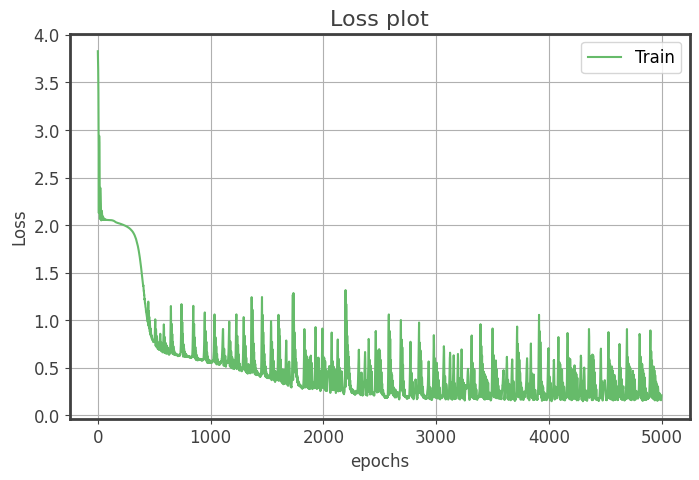

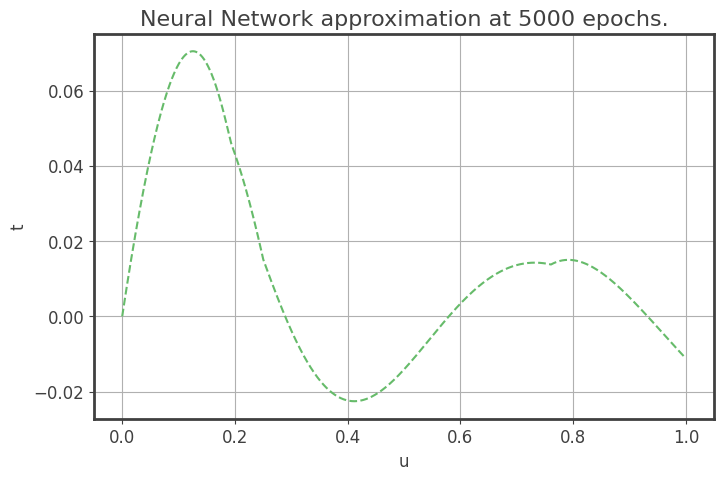

In [13]:
start = time.time()
solver.fit(max_epochs=5000)
plot_loss(solver)
plot_results(solver)

In [ ]:
time.time()-start

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params = count_parameters(nets[0])
print(f'Total number of parameters: {num_params}')